In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

In [3]:
sns.set_theme(style="whitegrid", palette="muted")
pd .set_option('display.max_columns', None)

In [4]:
city_df=pd.read_csv("../data/processed/zomato_clean.csv")
rated_df=city_df[city_df["aggregate_rating"]>0].copy()

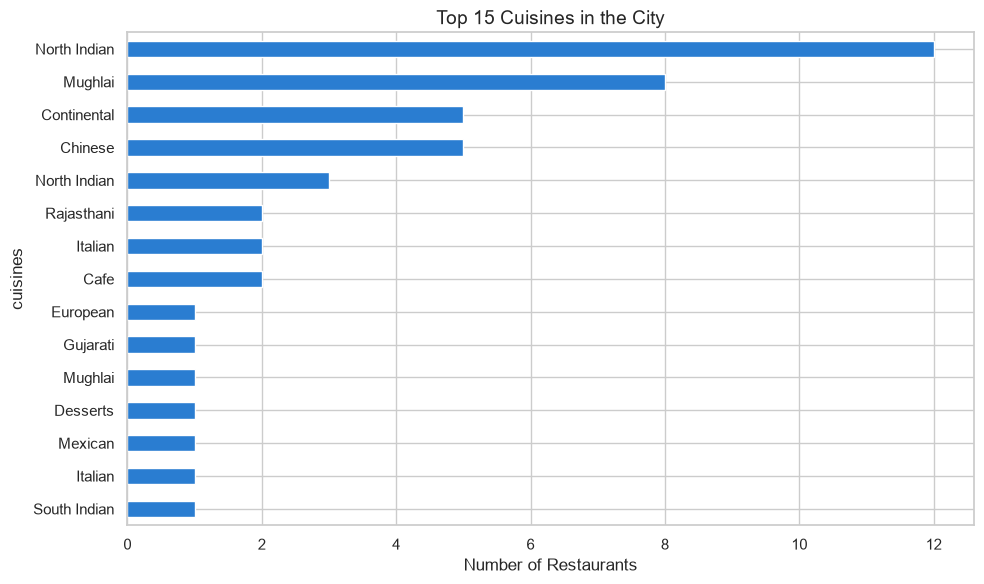

In [6]:
#Top Cuisines
cuisine_series=city_df["cuisines"].dropna().str.split(",")
top_cuisines=cuisine_series.explode().value_counts().head(15)

fig,ax=plt.subplots(figsize=(10,6))
top_cuisines.sort_values().plot(kind="barh",color="#2a7dd1",ax=ax)
ax.set_title("Top 15 Cuisines in the City",fontsize=14)
ax.set_xlabel("Number of Restaurants")
plt.tight_layout()
plt.savefig("../output/charts/01_top_cuisines.png", dpi=150)
plt.show()




Pearson Correlation: -0.099 | P-value:0.679184
Verdict Weak-price does not reliably predict quality here


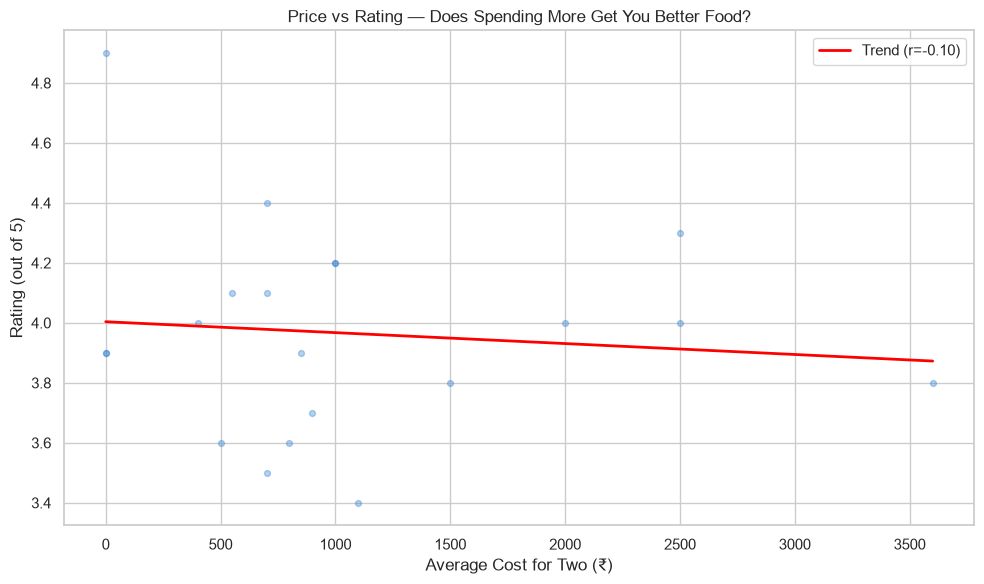

In [7]:
#Price vs Rating
corr,pval=stats.pearsonr(rated_df["average_cost_for_two"],
                         rated_df["aggregate_rating"])
print(f"Pearson Correlation: {corr:.3f} | P-value:{pval:4f}")

if abs(corr)<0.3:
    print("Verdict Weak-price does not reliably predict quality here")
elif abs(corr)<0.6:
    print("Verdict:Moderate realtionship between price and rating ")
else:
    print("verdict:Strong relationship")

fig,ax=plt.subplots(figsize=(10,6))
ax.scatter(rated_df["average_cost_for_two"],
           rated_df["aggregate_rating"],
           alpha=0.35,s=18,color='#2a7dd1')
m, b = np.polyfit(rated_df["average_cost_for_two"], rated_df["aggregate_rating"], 1)
x_line = np.linspace(rated_df["average_cost_for_two"].min(),
                     rated_df["average_cost_for_two"].max(), 200)
ax.plot(x_line, m*x_line + b, color="red", lw=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Average Cost for Two (₹)")
ax.set_ylabel("Rating (out of 5)")
ax.set_title("Price vs Rating — Does Spending More Get You Better Food?")
ax.legend()
plt.tight_layout()
plt.savefig("../output/charts/02_price_vs_rating.png", dpi=150)
plt.show()


C:\Users\khush\AppData\Local\Temp\ipykernel_9320\2539065262.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_stats, x="price_range", y="avg_rating",


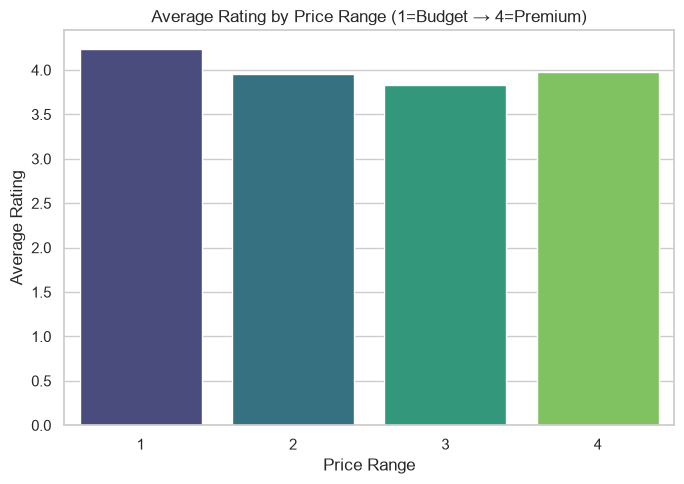

In [9]:
#Rating by price range
price_stats=rated_df.groupby("price_range").agg(
    avg_rating=("aggregate_rating","mean"),
    count=("aggregate_rating","count")
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=price_stats, x="price_range", y="avg_rating",
            palette="viridis", ax=ax)
ax.set_title("Average Rating by Price Range (1=Budget → 4=Premium)")
ax.set_xlabel("Price Range")
ax.set_ylabel("Average Rating")
plt.tight_layout()
plt.savefig("../output/charts/03_rating_by_price_range.png", dpi=150)
plt.show()

C:\Users\khush\AppData\Local\Temp\ipykernel_9320\2835546229.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rated_df, x="has_online_delivery", y="aggregate_rating",


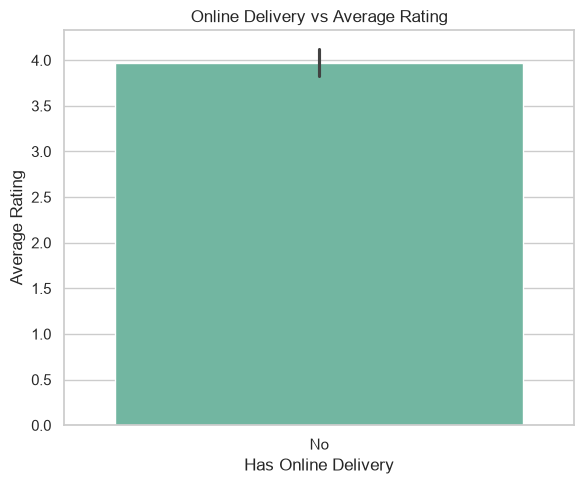

In [11]:
#Online delivery vs rating ───────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=rated_df, x="has_online_delivery", y="aggregate_rating",
            palette="Set2", ax=ax)
ax.set_title("Online Delivery vs Average Rating")
ax.set_xlabel("Has Online Delivery")
ax.set_ylabel("Average Rating")
plt.tight_layout()
plt.savefig("../output/charts/04_delivery_vs_rating.png", dpi=150)
plt.show()


C:\Users\khush\AppData\Local\Temp\ipykernel_9320\3431542106.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=underserved, y="locality", x="underserved_score",


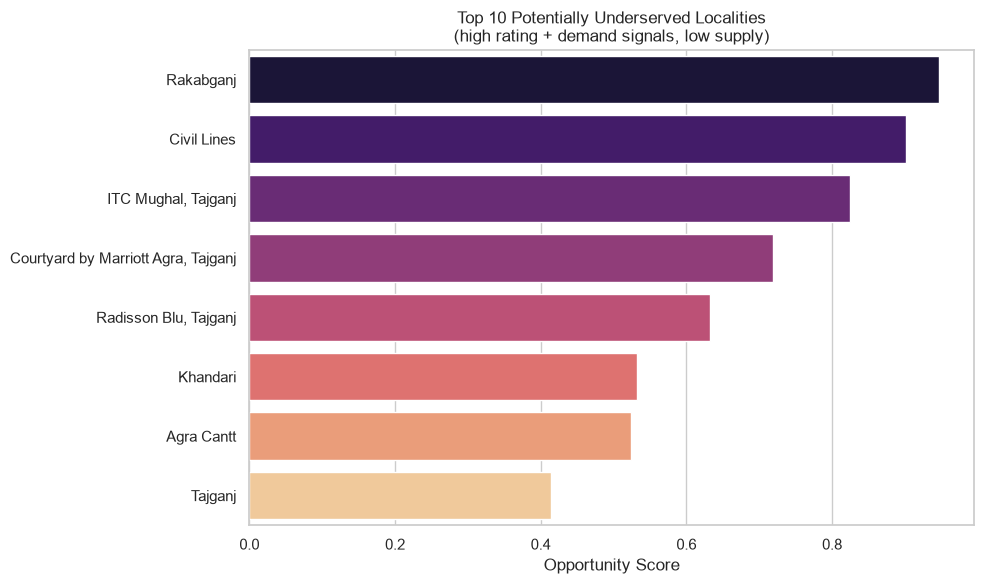

                              locality  restaurant_count  avg_rating  \
6                            Rakabganj                 1    4.100000   
1                          Civil Lines                 2    4.100000   
3                  ITC Mughal, Tajganj                 2    4.150000   
2  Courtyard by Marriott Agra, Tajganj                 1    4.000000   
5                Radisson Blu, Tajganj                 2    3.850000   
4                             Khandari                 1    3.600000   
0                           Agra Cantt                 3    3.666667   
7                              Tajganj                 8    4.050000   

    avg_votes  underserved_score  
6  121.000000           0.947440  
1  132.000000           0.901299  
3   87.000000           0.825123  
2   45.000000           0.718182  
5   74.500000           0.632751  
4   59.000000           0.532184  
0  101.666667           0.523775  
7  118.125000           0.413558  


In [13]:
#Underserved locality score 
locality_stats = rated_df.groupby("locality").agg(
    restaurant_count=("restaurant_id","count"),
    avg_rating=("aggregate_rating","mean"),
    avg_votes=("votes","mean"),
    avg_cost=("average_cost_for_two","mean")
).reset_index()

scaler = MinMaxScaler()
locality_stats[["cnt_sc","rat_sc","vot_sc"]] = scaler.fit_transform(
    locality_stats[["restaurant_count","avg_rating","avg_votes"]])
# Score: reward HIGH rating + HIGH votes + LOW restaurant count (= opportunity)
locality_stats["underserved_score"] = (
    (1 - locality_stats["cnt_sc"]) * 0.50 +
    locality_stats["rat_sc"]       * 0.30 +
    locality_stats["vot_sc"]       * 0.20
)
underserved = locality_stats.sort_values("underserved_score", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=underserved, y="locality", x="underserved_score",
            palette="magma", ax=ax)
ax.set_title("Top 10 Potentially Underserved Localities\n(high rating + demand signals, low supply)")
ax.set_xlabel("Opportunity Score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../output/charts/05_underserved_localities.png", dpi=150)
plt.show()

print(underserved[["locality","restaurant_count","avg_rating","avg_votes","underserved_score"]])

